# 1. Prepare input

In [41]:
import pandas as pd
import numpy as np
from pathlib import Path

input_file = Path("outputs/model2_conditional_volatility.csv")

tvp_data = pd.read_csv(
    input_file,
    parse_dates=["Date"]
)

tvp_data = (
    tvp_data
    .sort_values("Date")
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .set_index("Date")
)

tvp_data.head()

,BTC,SJC,VNINDEX
Date,,,
2023-08-02,2.276917,0.210944,1.209943
2023-08-03,2.391194,0.211427,1.100940
2023-08-04,2.308372,0.228317,1.160359
2023-08-07,2.267835,0.233111,1.120516
2023-08-08,2.197017,0.232300,1.075406


In [42]:
expected_columns = ["BTC", "SJC", "VNINDEX"]

assert list(tvp_data.columns) == expected_columns
assert tvp_data.index.is_monotonic_increasing
assert not tvp_data.isna().any().any()
assert (tvp_data > 0).all().all()

print("Shape:", tvp_data.shape)
print("Date range:", tvp_data.index.min(), "→", tvp_data.index.max())
print(tvp_data.describe())

Shape: (747, 3)
Date range: 2023-08-02 00:00:00 → 2026-07-31 00:00:00
              BTC         SJC     VNINDEX
count  747.000000  747.000000  747.000000
mean     3.138430    1.584696    1.109501
std      0.543944    0.796758    0.413432
min      2.079419    0.210944    0.610955
25%      2.758324    1.090123    0.852673
50%      3.100129    1.431278    1.007766
75%      3.437928    1.921690    1.234266
max      5.646079    5.907931    3.983911


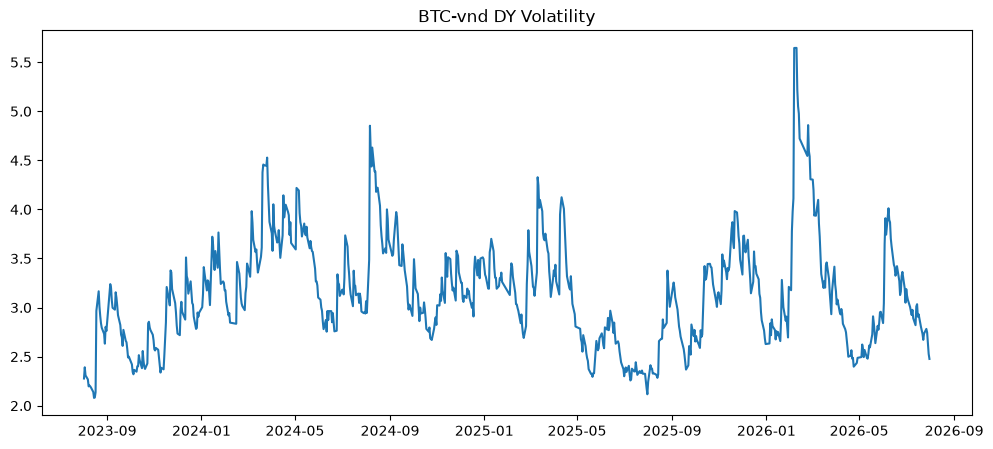

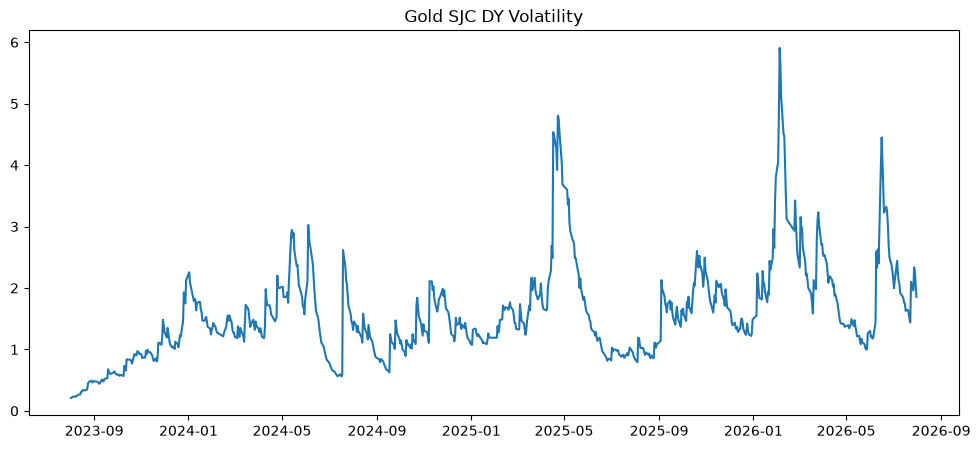

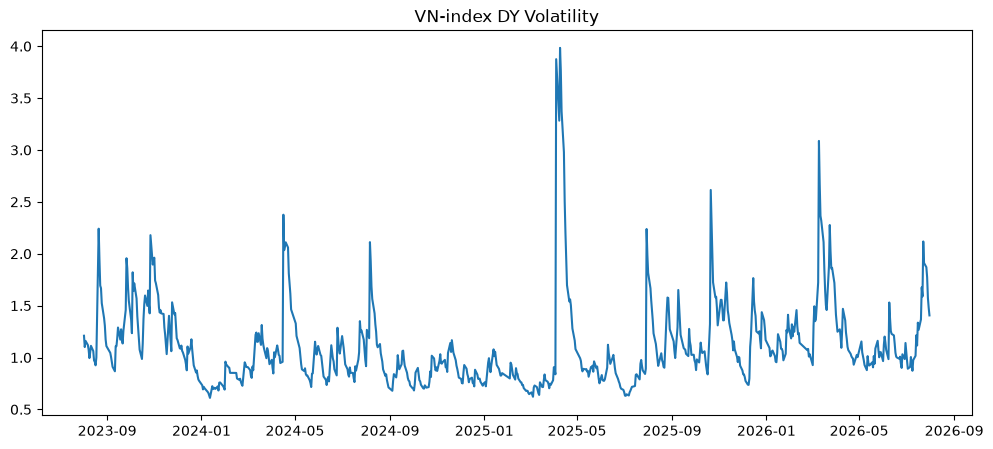

In [43]:
# Vẽ plot dữ liệu các prices

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(tvp_data['BTC'])
plt.title("BTC-vnd DY Volatility")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(tvp_data['SJC'])
plt.title("Gold SJC DY Volatility")
plt.show()

plt.figure(figsize=(12,5))
plt.plot(tvp_data['VNINDEX'])
plt.title("VN-index DY Volatility")
plt.show()

# 2. Stationary

## ADF, PP và KPSS test

Vì volatility không dao động quanh 0, luôn dương, nên lựa chọn test tính dừng có drift ('c')

In [44]:
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
from arch.unitroot import PhillipsPerron

In [45]:
vol_cols = ["BTC", "SJC", "VNINDEX"]

stationarity_results = []


for asset in vol_cols:

    x = (
        tvp_data[asset]
        .dropna()
        .astype(float)
    )

    # 1. ADF TEST
    # H0: Unit root / Non-stationary
    adf_result = adfuller(
        x,
        regression="c",
        autolag="AIC"
    )

    adf_stat = adf_result[0]
    adf_p = adf_result[1]
    adf_lag = adf_result[2]


    # 2. PHILLIPS-PERRON TEST
    # H0: Unit root / Non-stationary
    pp_result = PhillipsPerron(
        x,
        trend="c"
    )

    pp_stat = pp_result.stat
    pp_p = pp_result.pvalue


    # 3. KPSS TEST
    # H0: Stationary
    kpss_result = kpss(
        x,
        regression="c",
        nlags="auto"
    )

    kpss_stat = kpss_result[0]
    kpss_p = kpss_result[1]
    kpss_lag = kpss_result[2]


    stationarity_results.append({

        "Asset": asset,

        "ADF Statistic": adf_stat,
        "ADF p-value": adf_p,
        "ADF Lag": adf_lag,

        "PP Statistic": pp_stat,
        "PP p-value": pp_p,

        "KPSS Statistic": kpss_stat,
        "KPSS p-value": kpss_p,
        "KPSS Lag": kpss_lag
    })


# ============================================================
# RESULT TABLE
# ============================================================

stationarity_table = pd.DataFrame(
    stationarity_results
).set_index("Asset")


print("=" * 50)
print("STATIONARITY TESTS - CONDITIONAL VOLATILITY")
print("=" * 50)
print(stationarity_table.round(6).to_string())


STATIONARITY TESTS - CONDITIONAL VOLATILITY
         ADF Statistic  ADF p-value  ADF Lag  PP Statistic  PP p-value  KPSS Statistic  KPSS p-value  KPSS Lag
Asset                                                                                                         
BTC          -4.818064     0.000050        3     -4.722934    0.000076        0.177615          0.10        17
SJC          -4.944503     0.000029        5     -4.220941    0.000607        1.194747          0.01        17
VNINDEX      -7.119816     0.000000        2     -6.860004    0.000000        0.294107          0.10        16


/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_13804/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_13804/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(
/var/folders/86/1060tmrx2ssckzy0244rh3jr0000gn/T/ipykernel_13804/723959834.py:40: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(


### Kết quả test tính dừng

* BTC volatility: dừng ở ADF test, PP test và KPSS test
* SJC volatility: chuỗi dừng ở ADF test và PP test, tuy nhiên KPSS cho kết quả không nhất quán, vì thế cần kiểm tra điểm gãy cấu trúc của dữ liệu
* VN-Index volatility: dừng ở ADF test, PP và KPSS test

## Xem xét structural breaks đối với SJC

In [47]:
import pandas as pd
from statsmodels.tsa.stattools import zivot_andrews

x = (
    tvp_data["SJC"]
    .dropna()
    .astype(float)
)

za_stat, za_pvalue, za_cv, za_baselag, za_break = zivot_andrews(
    x,
    trim=0.15,
    maxlag=None,
    regression="ct",
    autolag="AIC"
)

break_date = x.index[za_break]

print("=" * 50)
print("ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY")
print("=" * 50)

print(f"ZA Statistic       : {za_stat:.6f}")
print(f"p-value            : {za_pvalue:.6f}")
print(f"Selected lag       : {za_baselag}")
print(f"Break index        : {za_break}")
print(f"Estimated break date: {break_date}")

print("\nCritical values:")
for level, value in za_cv.items():
    print(f"{level}: {value:.6f}")

ZIVOT-ANDREWS TEST - SJC CONDITIONAL VOLATILITY
ZA Statistic       : -6.113864
p-value            : 0.001885
Selected lag       : 5
Break index        : 207
Estimated break date: 2024-06-04 00:00:00

Critical values:
1%: -5.575560
5%: -5.073320
10%: -4.826680


### Kết quả ZA test của SJC

Chuỗi SJC DY Volatility có đủ cơ sở bác bỏ H0 của ZA test, điểm gãy cấu trúc được estimate vào ngày 04/06/2024. 

* H0: Chuỗi có nghiệm đơn vị và có điểm gãy cấu trúc
* H1: Chuỗi dừng xung quanh một xu hướng gãy có cấu trúc

# 3. Lag p TVP-VAR

Theo 4 tiêu chí thông tin:
1. AIC
2. BIC
3. FPE
4. HQIC

In [48]:
from statsmodels.tsa.api import VAR

# Endogenous variables
var_data = (
    tvp_data[
        ["BTC", "SJC", "VNINDEX"]
    ]
    .dropna()
    .copy()
)

# VAR lag-order selection

var_model = VAR(var_data)

lag_selection = var_model.select_order(
    maxlags=20,
    trend="c"
)

print("=" * 50)
print("PRELIMINARY LAG ORDER SELECTION FOR TVP-VAR")
print("=" * 50)

print(lag_selection.summary())

print("\nSelected lag by criterion:")
print("AIC  :", lag_selection.aic)
print("BIC  :", lag_selection.bic)
print("HQIC :", lag_selection.hqic)
print("FPE  :", lag_selection.fpe)

PRELIMINARY LAG ORDER SELECTION FOR TVP-VAR
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -3.627      -3.608     0.02659      -3.620
1       -9.674     -9.599*   6.287e-05     -9.645*
2       -9.666      -9.533   6.343e-05      -9.614
3      -9.683*      -9.494  6.234e-05*      -9.610
4       -9.682      -9.435   6.243e-05      -9.587
5       -9.676      -9.373   6.280e-05      -9.559
6       -9.666      -9.306   6.340e-05      -9.527
7       -9.665      -9.249   6.346e-05      -9.504
8       -9.668      -9.195   6.325e-05      -9.486
9       -9.677      -9.147   6.270e-05      -9.473
10      -9.664      -9.077   6.354e-05      -9.437
11      -9.647      -9.003   6.463e-05      -9.399
12      -9.632      -8.932   6.559e-05      -9.362
13      -9.645      -8.887   6.479e-05      -9.352
14      -9.629      -8.815   6.583e-05      -9.315
15      -9.611      -8.740   6.699e-05

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


Theo BIC = 1 và HQIC = 1, chọn baseline p = 1
TVP-VAR(1)

# 4. TVP-VAR(1)

In [76]:
import numpy as np
import pandas as pd
from statsmodels.tsa.api import VAR

# TVP-VAR(1) - KALMAN FILTER WITH FORGETTING FACTORS
# Endogenous variables
var_data = (
    tvp_data[["BTC", "SJC", "VNINDEX"]]
    .dropna()
    .astype(float)
    .copy()
)

Y = var_data.to_numpy()

T, K = Y.shape

# TVP-VAR lag order
p = 1

# Forgetting factors

# Coefficient forgetting factor
lambda_beta = 0.999

# Covariance forgetting factor
kappa_sigma = 0.96

# ============================================================
# 1. INITIAL VALUES FROM STATIC VAR(1)
# ============================================================

static_var = VAR(var_data)

static_fit = static_var.fit(
    maxlags=1,
    trend="c"
)

# Static VAR coefficient matrix
# rows    = constant + lagged variables
# columns = equations
B0 = static_fit.params.to_numpy()

# Number of regressors per equation
# constant + K lagged variables
m = K + 1

# Vectorize coefficient matrix
beta_prev = B0.flatten(order="F")

n_beta = len(beta_prev)

# Initial state covariance
P_prev = np.eye(n_beta) * 0.01

# Initial shock covariance matrix
Sigma_prev = np.asarray(
    static_fit.sigma_u
)

# Initial VAR(1) coefficients
A0 = B0[1:, :].T

# Initial intercept
c0 = B0[0, :]


# ============================================================
# 2. STORAGE
# ============================================================

beta_store = np.zeros(
    (T, n_beta)
)

A_store = np.zeros(
    (T, K, K)
)

constant_store = np.zeros(
    (T, K)
)

Sigma_store = np.zeros(
    (T, K, K)
)

innovation_store = np.full(
    (T, K),
    np.nan
)


# ============================================================
# INITIALIZE t = 0
# ============================================================

beta_store[0] = beta_prev

A_store[0] = A0

constant_store[0] = c0

Sigma_store[0] = Sigma_prev

# 3. TVP-VAR(1) KALMAN FILTER
# ============================================================

I_beta = np.eye(n_beta)

for t in range(1, T):

    # --------------------------------------------------------
    # Observation vector
    #
    # z_t = [1, y_(t-1)]
    # --------------------------------------------------------

    z_t = np.concatenate(
        ([1.0], Y[t - 1])
    )

    # Observation matrix
    #
    # y_t = H_t beta_t + epsilon_t
    #
    H_t = np.kron(
        np.eye(K),
        z_t.reshape(1, -1)
    )


    # ========================================================
    # PREDICTION STEP
    # ========================================================

    # Random walk:
    # beta_t|t-1 = beta_(t-1)|t-1

    beta_pred = beta_prev.copy()

    # Forgetting-factor evolution of state uncertainty
    P_pred = P_prev / lambda_beta


    # ========================================================
    # INNOVATION
    # ========================================================

    y_pred = H_t @ beta_pred

    innovation = Y[t] - y_pred


    # Forecast covariance
    F_t = (
        H_t
        @ P_pred
        @ H_t.T
        + Sigma_prev
    )

    # Numerical protection
    F_t += np.eye(K) * 1e-10


    # ========================================================
    # KALMAN GAIN
    # ========================================================

    K_gain = (
        P_pred
        @ H_t.T
        @ np.linalg.inv(F_t)
    )


    # ========================================================
    # UPDATE COEFFICIENTS
    # ========================================================

    beta_new = (
        beta_pred
        + K_gain @ innovation
    )


    # Joseph-style covariance update
    KH = K_gain @ H_t

    P_new = (
        (I_beta - KH)
        @ P_pred
        @ (I_beta - KH).T
        + K_gain
        @ Sigma_prev
        @ K_gain.T
    )

    # Force symmetry
    P_new = (P_new + P_new.T) / 2


    # UPDATE SHOCK COVARIANCE MATRIX
    # ========================================================

    Sigma_new = (
        kappa_sigma * Sigma_prev
        +
        (1 - kappa_sigma)
        * np.outer(
            innovation,
            innovation
        )
    )

    # Force symmetry
    Sigma_new = (
        Sigma_new
        + Sigma_new.T
    ) / 2

    # Numerical protection
    Sigma_new += np.eye(K) * 1e-10


    # ========================================================
    # RECOVER VAR COEFFICIENT MATRIX
    # ========================================================

    B_t = beta_new.reshape(
        (m, K),
        order="F"
    )

    # Constant
    constant_t = B_t[0, :]

    # VAR(1) coefficient matrix
    #
    # y_t = c_t + A_t y_(t-1) + eps_t
    #
    A_t = B_t[1:, :].T


    # ========================================================
    # STORE RESULTS
    # ========================================================

    beta_store[t] = beta_new

    constant_store[t] = constant_t

    A_store[t] = A_t

    Sigma_store[t] = Sigma_new

    innovation_store[t] = innovation


    # Prepare next iteration
    beta_prev = beta_new
    P_prev = P_new
    Sigma_prev = Sigma_new


# ============================================================
# 4. CREATE TIME INDEX
# ============================================================

tvp_dates = var_data.index


# ============================================================
# 5. BASIC OUTPUT
# ============================================================

print("=" * 60)
print("TVP-VAR(1) ESTIMATION COMPLETED")
print("=" * 60)

print(f"Observations             : {T}")
print(f"Number of variables      : {K}")
print(f"Lag order                : {p}")
print(f"Coefficient forgetting λ : {lambda_beta}")
print(f"Covariance forgetting κ  : {kappa_sigma}")

print("\nVariables:")
print(list(var_data.columns))

print("\nA_t shape:")
print(A_store.shape)

print("\nSigma_t shape:")
print(Sigma_store.shape)

print("\nFinal TVP-VAR coefficient matrix A_T:")
print(
    pd.DataFrame(
        A_store[-1],
        index=var_data.columns,
        columns=var_data.columns
    ).round(6)
)

print("\nFinal shock covariance matrix Sigma_T:")
print(
    pd.DataFrame(
        Sigma_store[-1],
        index=var_data.columns,
        columns=var_data.columns
    ).round(6)
)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


TVP-VAR(1) ESTIMATION COMPLETED
Observations             : 747
Number of variables      : 3
Lag order                : 1
Coefficient forgetting λ : 0.999
Covariance forgetting κ  : 0.96

Variables:
['BTC', 'SJC', 'VNINDEX']

A_t shape:
(747, 3, 3)

Sigma_t shape:
(747, 3, 3)

Final TVP-VAR coefficient matrix A_T:
              BTC       SJC   VNINDEX
BTC      0.950943  0.014676 -0.009996
SJC      0.038066  0.950629  0.042509
VNINDEX  0.009671  0.014850  0.891706

Final shock covariance matrix Sigma_T:
              BTC       SJC   VNINDEX
BTC      0.015976 -0.001710 -0.000933
SJC     -0.001710  0.077807  0.002076
VNINDEX -0.000933  0.002076  0.026535


# 5. Stability TVP-VAR(1)

TVP-VAR(1) STABILITY CHECK
Observations              : 747
Stable periods            : 733
Unstable periods          : 14
Share stable              : 0.9813

Spectral radius summary:
count    747.000000
mean       0.971370
std        0.013924
min        0.927852
25%        0.957637
50%        0.972755
75%        0.982227
max        1.026851
Name: Spectral Radius, dtype: float64

Maximum spectral radius:
1.0268512230532167

Date of maximum spectral radius:
2024-01-02 00:00:00

Number of unstable dates:
14

First unstable periods:
            Spectral Radius  Stable
Date                               
2023-11-29         1.013382   False
2023-12-26         1.015893   False
2023-12-27         1.010754   False
2023-12-28         1.005072   False
2023-12-29         1.022009   False
2024-01-02         1.026851   False
2024-01-03         1.017709   False
2024-01-04         1.017123   False
2024-01-05         1.011961   False
2024-01-08         1.002773   False


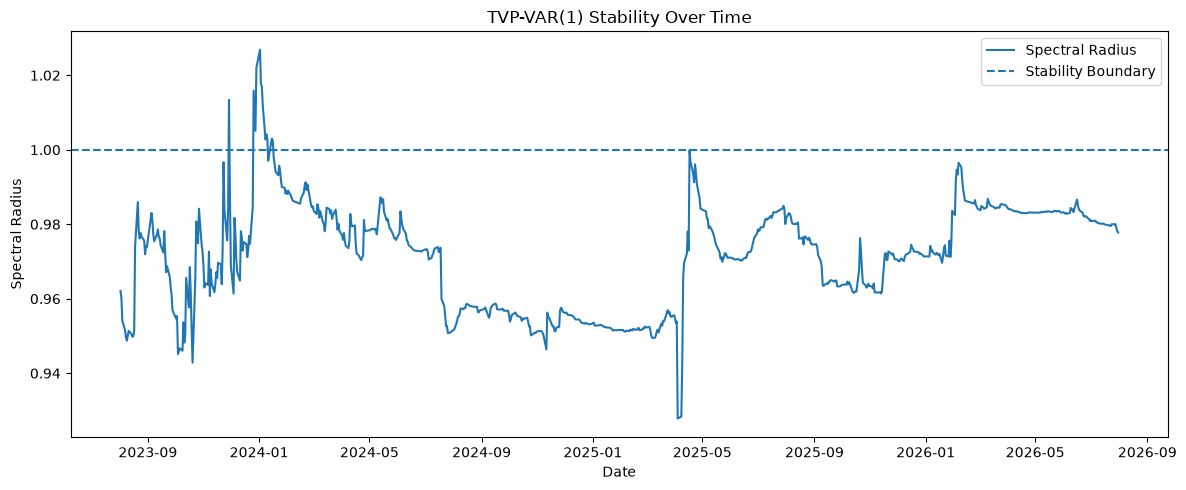

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# TVP-VAR(1) STABILITY CHECK
# Spectral radius of A_t at each time point
# ============================================================

T = A_store.shape[0]

spectral_radius = np.zeros(T)

for t in range(T):

    eigenvalues = np.linalg.eigvals(A_store[t])

    spectral_radius[t] = np.max(
        np.abs(eigenvalues)
    )


# ============================================================
# CREATE RESULT TABLE
# ============================================================

stability_table = pd.DataFrame(
    {
        "Spectral Radius": spectral_radius,
        "Stable": spectral_radius < 1
    },
    index=tvp_dates[:T]
)


# ============================================================
# SUMMARY
# ============================================================

n_stable = stability_table["Stable"].sum()
n_unstable = (~stability_table["Stable"]).sum()

stable_ratio = (
    n_stable / len(stability_table)
)


print("=" * 60)
print("TVP-VAR(1) STABILITY CHECK")
print("=" * 60)

print(f"Observations              : {T}")
print(f"Stable periods            : {n_stable}")
print(f"Unstable periods          : {n_unstable}")
print(f"Share stable              : {stable_ratio:.4f}")

print("\nSpectral radius summary:")
print(
    stability_table[
        "Spectral Radius"
    ].describe().round(6)
)

print("\nMaximum spectral radius:")
print(
    stability_table[
        "Spectral Radius"
    ].max()
)

print("\nDate of maximum spectral radius:")
print(
    stability_table[
        "Spectral Radius"
    ].idxmax()
)


# ============================================================
# UNSTABLE DATES
# ============================================================

unstable_dates = stability_table[
    stability_table["Stable"] == False
]

print("\nNumber of unstable dates:")
print(len(unstable_dates))

if len(unstable_dates) > 0:

    print("\nFirst unstable periods:")
    print(
        unstable_dates.head(10)
    )


# ============================================================
# PLOT
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    stability_table.index,
    stability_table["Spectral Radius"],
    label="Spectral Radius"
)

plt.axhline(
    y=1,
    linestyle="--",
    label="Stability Boundary"
)

plt.xlabel("Date")
plt.ylabel("Spectral Radius")
plt.title(
    "TVP-VAR(1) Stability Over Time"
)

plt.legend()
plt.tight_layout()
plt.show()

In [78]:
unstable_dates = stability_table[
    stability_table["Spectral Radius"] >= 1
]

print(unstable_dates)

mask = stability_table["Spectral Radius"] >= 1

positions = np.where(mask)[0]

unstable = stability_table.loc[mask].copy()
unstable["Position"] = positions

unstable["Episode"] = (
    unstable["Position"]
    .diff()
    .ne(1)
    .cumsum()
)

episodes = (
    unstable
    .groupby("Episode")
    .agg(
        Start=("Position",
               lambda x: stability_table.index[x.iloc[0]]),
        End=("Position",
             lambda x: stability_table.index[x.iloc[-1]]),
        Duration=("Position", "size"),
        Max_Radius=("Spectral Radius", "max")
    )
)

print(episodes)

            Spectral Radius  Stable
Date                               
2023-11-29         1.013382   False
2023-12-26         1.015893   False
2023-12-27         1.010754   False
2023-12-28         1.005072   False
2023-12-29         1.022009   False
2024-01-02         1.026851   False
2024-01-03         1.017709   False
2024-01-04         1.017123   False
2024-01-05         1.011961   False
2024-01-08         1.002773   False
2024-01-09         1.004173   False
2024-01-10         1.002969   False
2024-01-15         1.002987   False
2024-01-16         1.002390   False
             Start        End  Duration  Max_Radius
Episode                                            
1       2023-11-29 2023-11-29         1    1.013382
2       2023-12-26 2024-01-10        11    1.026851
3       2024-01-15 2024-01-16         2    1.002987


In [79]:
import numpy as np
import pandas as pd

# ============================================================
# TVP-GFEVD - H = 10
# ============================================================

H = 10

T, K, _ = A_store.shape

# Storage:
# theta_store[t, i, j]
# = contribution of shock j
#   to forecast error variance of variable i
theta_store = np.zeros((T, K, K))


# ============================================================
# LOOP OVER TIME
# ============================================================

for t in range(T):

    A_t = A_store[t]
    Sigma_t = Sigma_store[t]

    # --------------------------------------------------------
    # 1. COMPUTE MA COEFFICIENTS PHI_h,t
    # --------------------------------------------------------

    # Phi_0 = I
    phi_list = [np.eye(K)]

    for h in range(1, H):
        phi_h = np.linalg.matrix_power(A_t, h)
        phi_list.append(phi_h)


    # --------------------------------------------------------
    # 2. GENERALIZED FEVD
    # --------------------------------------------------------

    theta_t = np.zeros((K, K))

    for i in range(K):

        # Denominator:
        # sum_h (e_i' Phi_h Sigma Phi_h' e_i)

        denominator = 0.0

        for h in range(H):

            Phi_h = phi_list[h]

            temp = (
                Phi_h
                @ Sigma_t
                @ Phi_h.T
            )

            denominator += temp[i, i]


        # Contributions from shock j
        for j in range(K):

            sigma_jj = Sigma_t[j, j]

            numerator = 0.0

            for h in range(H):

                Phi_h = phi_list[h]

                # e_i' Phi_h Sigma e_j
                contribution = (
                    Phi_h
                    @ Sigma_t
                )[i, j]

                numerator += (
                    contribution ** 2
                )

            theta_t[i, j] = (
                numerator
                / sigma_jj
                / denominator
            )


    # --------------------------------------------------------
    # 3. ROW NORMALIZATION
    # --------------------------------------------------------

    row_sums = theta_t.sum(
        axis=1,
        keepdims=True
    )

    theta_t_normalized = (
        theta_t / row_sums
    )

    theta_store[t] = theta_t_normalized


# ============================================================
# BASIC CHECK
# ============================================================

print("=" * 60)
print("TVP-GFEVD COMPLETED")
print("=" * 60)

print(f"Horizon H      : {H}")
print(f"Observations   : {T}")
print(f"Variables      : {K}")

print("\nTheta shape:")
print(theta_store.shape)


# ============================================================
# CHECK FINAL PERIOD
# ============================================================

theta_final = pd.DataFrame(
    theta_store[-1] * 100,
    index=var_data.columns,
    columns=var_data.columns
)

print("\nFinal-period normalized GFEVD (%):")
print(
    theta_final.round(4)
)

print("\nRow sums (%):")
print(
    theta_final.sum(axis=1).round(6)
)

TVP-GFEVD COMPLETED
Horizon H      : 10
Observations   : 747
Variables      : 3

Theta shape:
(747, 3, 3)

Final-period normalized GFEVD (%):
             BTC      SJC  VNINDEX
BTC      98.0591   1.3378   0.6031
SJC       0.2640  97.9587   1.7773
VNINDEX   0.1121   2.6404  97.2476

Row sums (%):
BTC        100.0
SJC        100.0
VNINDEX    100.0
dtype: float64


## Đọc kết quả của TVP-VAR(1)

| Receiver ↓ / Shock → | BTC | SJC | VNINDEX |
|---|---:|---:|---:|
| BTC | 98.0591 | 1.3378 | 0.6031 |
| SJC | 0.2640 | 97.9587 | 1.7773 |
| VNINDEX | 0.1121 | 2.6404 | 97.2476 |

In [81]:
print("Any NaN:",np.isnan(theta_store).any())
print("Any Inf:",np.isinf(theta_store).any())
print("Minimum:",theta_store.min())
print("Maximum:",theta_store.max())
print("Maximum row-sum error:",np.max(np.abs(theta_store.sum(axis=2) - 1)))

Any NaN: False
Any Inf: False
Minimum: 3.392102022390738e-06
Maximum: 0.9997714885270569
Maximum row-sum error: 3.3306690738754696e-16


# 6. Connectedness measure theo thời gian

In [86]:
import numpy as np
import pandas as pd

# ============================================================
# DYNAMIC CONNECTEDNESS MEASURES
# FROM / TO / NET / TCI
# ============================================================

T, K, _ = theta_store.shape

variables = list(var_data.columns)

# Storage
TCI = np.zeros(T)

FROM = np.zeros((T, K))
TO = np.zeros((T, K))
NET = np.zeros((T, K))


# ============================================================
# CALCULATE CONNECTEDNESS AT EACH TIME t
# ============================================================

for t in range(T):

    theta_t = theta_store[t]

    # --------------------------------------------------------
    # FROM connectedness
    #
    # For variable i:
    # sum of off-diagonal elements in ROW i
    # --------------------------------------------------------

    FROM[t] = (
        theta_t.sum(axis=1)
        - np.diag(theta_t)
    )


    # --------------------------------------------------------
    # TO connectedness
    #
    # For variable j:
    # sum of off-diagonal elements in COLUMN j
    # --------------------------------------------------------

    TO[t] = (
        theta_t.sum(axis=0)
        - np.diag(theta_t)
    )


    # --------------------------------------------------------
    # NET connectedness
    #
    # Positive = net transmitter
    # Negative = net receiver
    # --------------------------------------------------------

    NET[t] = TO[t] - FROM[t]


    # --------------------------------------------------------
    # TOTAL CONNECTEDNESS INDEX
    #
    # Since theta rows sum to 1:
    #
    # TCI = sum of all off-diagonal shares / K
    # --------------------------------------------------------

    TCI[t] = (
        np.sum(theta_t)
        - np.trace(theta_t)
    ) / K


# ============================================================
# CONVERT TO PERCENTAGE POINTS
# ============================================================

TCI_pct = TCI * 100
FROM_pct = FROM * 100
TO_pct = TO * 100
NET_pct = NET * 100


# ============================================================
# CREATE DATAFRAMES
# ============================================================

tci_df = pd.DataFrame(
    {
        "TCI": TCI_pct
    },
    index=tvp_dates
)

from_df = pd.DataFrame(
    FROM_pct,
    index=tvp_dates,
    columns=variables
)

to_df = pd.DataFrame(
    TO_pct,
    index=tvp_dates,
    columns=variables
)

net_df = pd.DataFrame(
    NET_pct,
    index=tvp_dates,
    columns=variables
)


# ============================================================
# FINAL-PERIOD CONNECTEDNESS TABLE
# ============================================================

final_connectedness = pd.DataFrame(
    {
        "FROM": FROM_pct[-1],
        "TO": TO_pct[-1],
        "NET": NET_pct[-1]
    },
    index=variables
)


# ============================================================
# OUTPUT
# ============================================================

print("=" * 60)
print("TVP-VAR DYNAMIC CONNECTEDNESS - H=10")
print("=" * 60)

print("\nFinal-period connectedness (%):")
print(
    final_connectedness.round(4)
)

print(
    "\nFinal-period TCI:",
    round(TCI_pct[-1], 4),
    "%"
)

print("\nMean NET connectedness (%):")
print(
    net_df.mean().round(4)
)

print("\nCheck sum of NET at final period:")
print(
    round(
        final_connectedness["NET"].sum(),
        10
    )
)

TVP-VAR DYNAMIC CONNECTEDNESS - H=10

Final-period connectedness (%):
           FROM      TO     NET
BTC      1.9409  0.3761 -1.5648
SJC      2.0413  3.9781  1.9368
VNINDEX  2.7524  2.3804 -0.3720

Final-period TCI: 2.2449 %

Mean NET connectedness (%):
BTC        2.8759
SJC        2.2210
VNINDEX   -5.0969
dtype: float64

Check sum of NET at final period:
0.0


| Asset | FROM | TO | NET | Role cuối sample |
|---|---:|---:|---:|---|
| BTC | 1.9409 | 0.3761 | **−1.5648** | Receiver |
| SJC | 2.0413 | 3.9782 | **+1.9369** | Transmitter |
| VNINDEX | 2.7525 | 2.3804 | **−0.3721** | Receiver |

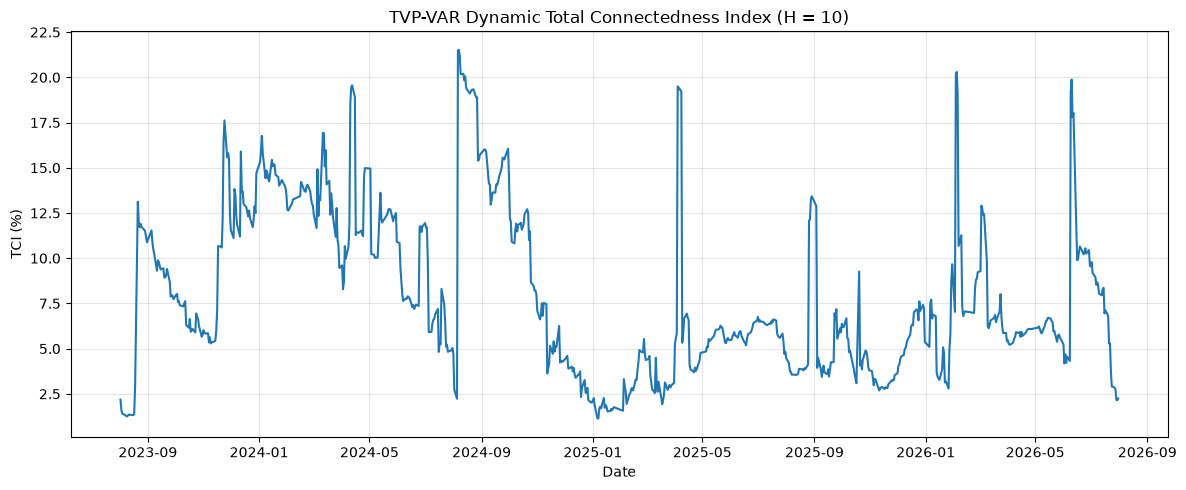

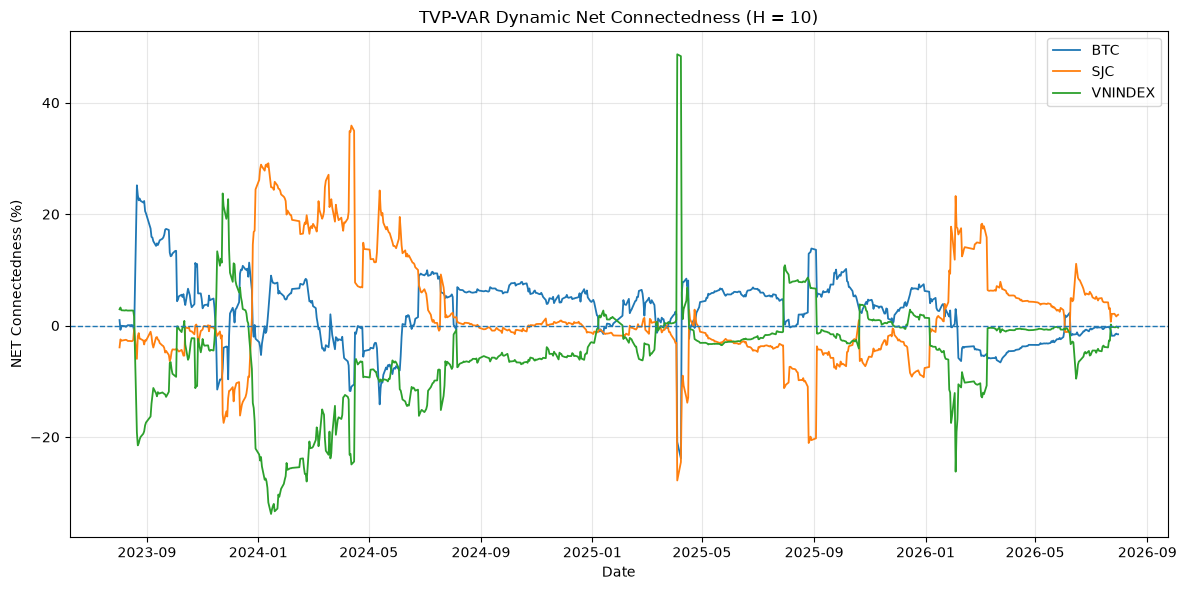

In [87]:
import matplotlib.pyplot as plt

# ============================================================
# 1. DYNAMIC TOTAL CONNECTEDNESS INDEX (TCI_t)
# ============================================================

plt.figure(figsize=(12, 5))

plt.plot(
    tci_df.index,
    tci_df["TCI"],
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("TCI (%)")
plt.title(
    "TVP-VAR Dynamic Total Connectedness Index "
    "(H = 10)"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()


# ============================================================
# 2. DYNAMIC NET CONNECTEDNESS
# ============================================================

plt.figure(figsize=(12, 6))

for asset in net_df.columns:

    plt.plot(
        net_df.index,
        net_df[asset],
        linewidth=1.3,
        label=asset
    )

# NET = 0 boundary:
# > 0 : Net transmitter
# < 0 : Net receiver
plt.axhline(
    y=0,
    linestyle="--",
    linewidth=1
)

plt.xlabel("Date")
plt.ylabel("NET Connectedness (%)")

plt.title(
    "TVP-VAR Dynamic Net Connectedness "
    "(H = 10)"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()
plt.show()

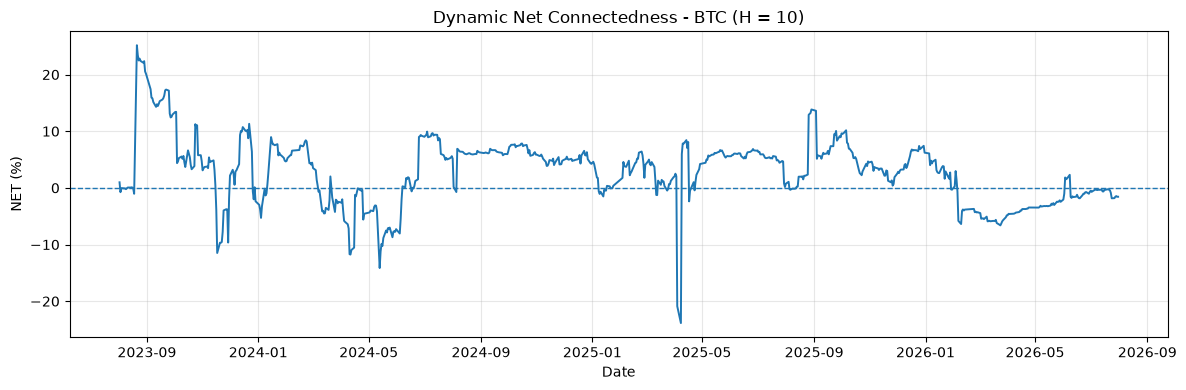

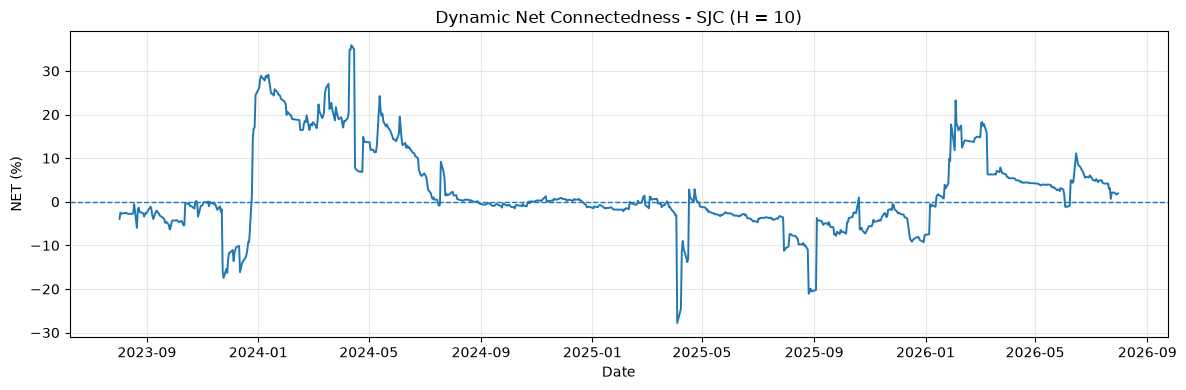

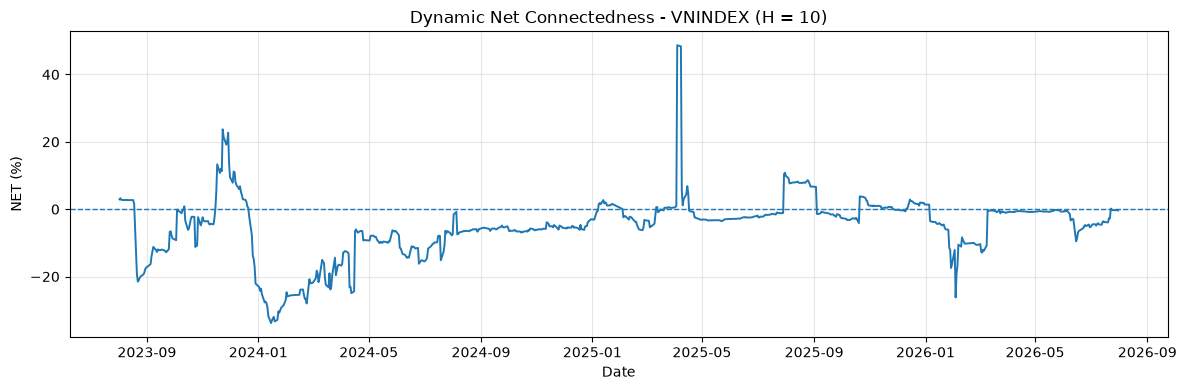

In [88]:
for asset in net_df.columns:

    plt.figure(figsize=(12, 4))

    plt.plot(
        net_df.index,
        net_df[asset],
        linewidth=1.4
    )

    plt.axhline(
        y=0,
        linestyle="--",
        linewidth=1
    )

    plt.xlabel("Date")
    plt.ylabel("NET (%)")

    plt.title(
        f"Dynamic Net Connectedness - {asset} "
        "(H = 10)"
    )

    plt.grid(
        alpha=0.3
    )

    plt.tight_layout()
    plt.show()

In [89]:
print("=" * 60)
print("AVERAGE TVP-VAR CONNECTEDNESS - H=10")
print("=" * 60)

print("\nMean TCI:")
print(tci_df["TCI"].mean())

print("\nMean FROM:")
print(from_df.mean().round(4))

print("\nMean TO:")
print(to_df.mean().round(4))

print("\nMean NET:")
print(net_df.mean().round(4))

AVERAGE TVP-VAR CONNECTEDNESS - H=10

Mean TCI:
7.92412042378382

Mean FROM:
BTC         6.4499
SJC         5.6875
VNINDEX    11.6349
dtype: float64

Mean TO:
BTC        9.3258
SJC        7.9085
VNINDEX    6.5380
dtype: float64

Mean NET:
BTC        2.8759
SJC        2.2210
VNINDEX   -5.0969
dtype: float64


# 7 Kết luận

## So sánh kết quả DY-VAR(9) và TVP-VAR(1)

### 1. Kết quả DY-VAR(9)

Tại horizon $H=10$, mô hình VAR(9) kết hợp với phân rã phương sai tổng quát GFEVD cho kết quả:

| Tài sản | OWN | FROM | TO | NET | Vai trò |
|---|---:|---:|---:|---:|---|
| BTC | 95,8504% | 4,1496% | 3,1278% | -1,0218% | Net receiver |
| SJC | 93,9896% | 6,0104% | 3,9990% | -2,0114% | Net receiver |
| VN-Index | 97,6583% | 2,3417% | 5,3749% | +3,0332% | Net transmitter |

Chỉ số kết nối tổng thể đạt:

$$
TCI_{DY}=4,1672\%.
$$

Kết quả cho thấy phần lớn biến động của mỗi tài sản được giải thích bởi các cú sốc nội tại. Tỷ lệ OWN lần lượt đạt 95,8504% đối với BTC, 93,9896% đối với SJC và 97,6583% đối với VN-Index.

VN-Index là nguồn truyền volatility ròng duy nhất vì có $NET>0$. Ngược lại, BTC và SJC là các thị trường nhận rủi ro ròng. SJC có mức FROM cao nhất, đạt 6,0104%, đồng thời có NET âm lớn nhất về trị tuyệt đối. Điều này cho thấy SJC chịu ảnh hưởng từ các cú sốc bên ngoài tương đối mạnh nhất trong hệ thống.

Kênh truyền nổi bật nhất là:

$$
VNINDEX \rightarrow SJC,
$$

với spillover ròng khoảng 4,35 điểm phần trăm. Như vậy, theo bức tranh trung bình của mô hình DY-VAR(9), biến động của VN-Index có xu hướng lan truyền sang thị trường vàng SJC.

### 2. Kết quả TVP-VAR(1)

#### 2.1. Trạng thái cuối mẫu

Tại thời điểm cuối mẫu, TVP-VAR(1) cho kết quả:

| Tài sản | OWN | FROM | TO | NET | Vai trò |
|---|---:|---:|---:|---:|---|
| BTC | 98,0591% | 1,9409% | 0,3761% | -1,5648% | Receiver |
| SJC | 97,9587% | 2,0413% | 3,9781% | +1,9368% | Transmitter |
| VN-Index | 97,2476% | 2,7524% | 2,3804% | -0,3720% | Receiver |

Chỉ số kết nối cuối mẫu là:

$$
TCI_{TVP,\,cuối}=2,2449\%.
$$

Ở cuối mẫu, mức độ kết nối thấp hơn kết quả DY-VAR(9). Các cú sốc riêng của từng tài sản chiếm tỷ trọng lớn hơn, trong khi spillover chéo giảm xuống.

Đáng chú ý, vai trò truyền và nhận rủi ro đã thay đổi. SJC chuyển thành net transmitter, còn VN-Index chuyển thành net receiver. BTC tiếp tục là net receiver và nhận nhiều volatility từ SJC hơn lượng volatility truyền sang các thị trường khác.

#### 2.2. Trung bình theo thời gian

Do TVP-VAR(1) cho phép các tham số thay đổi theo thời gian, cần phân biệt kết quả cuối mẫu với kết quả trung bình của toàn bộ giai đoạn. TCI trung bình của TVP-VAR(1) đạt:

$$
\overline{TCI}_{TVP}=7,9241\%.
$$

NET trung bình theo thời gian là:

| Tài sản | NET trung bình | Vai trò trung bình |
|---|---:|---|
| BTC | +2,8759% | Net transmitter |
| SJC | +2,2210% | Net transmitter |
| VN-Index | -5,0969% | Net receiver |

Do đó, trong phần lớn thời gian của mẫu, BTC và SJC có xu hướng truyền volatility ròng, còn VN-Index có xu hướng nhận volatility ròng. Tuy nhiên, cấu trúc này đã thay đổi vào cuối mẫu.

### 3. So sánh hai mô hình

| Chỉ tiêu | DY-VAR(9) | TVP-VAR(1), cuối mẫu |
|---|---:|---:|
| TCI | 4,1672% | 2,2449% |
| BTC | Receiver | Receiver |
| SJC | Receiver | Transmitter |
| VN-Index | Transmitter | Receiver |
| Kênh truyền nổi bật | VN-Index → SJC | SJC → BTC |

#### 3.1. Những điểm tương đồng

Cả hai mô hình đều cho thấy:

1. Mức độ connectedness tổng thể không cao.
2. OWN shocks chiếm tỷ trọng lớn, khoảng 94% đến 98%, các thị trường chưa phụ thuộc quá mạnh vào các cú sốc từ thị trường khác.
3. BTC có vai trò receiver tại cuối mẫu trong cả hai cách tiếp cận.

Điều này cho thấy ba thị trường vẫn có đặc điểm riêng tương đối rõ và lợi ích đa dạng hóa vẫn tồn tại trong giai đoạn nghiên cứu.

#### 3.2. Những điểm khác biệt

Khác biệt lớn nhất nằm ở vai trò truyền và nhận rủi ro:

- DY-VAR(9) là mô hình tĩnh, nên phản ánh một bức tranh tổng hợp cho toàn bộ giai đoạn. Theo kết quả này, VN-Index là net transmitter và SJC là net receiver.
- TVP-VAR(1) cho phép hệ số và ma trận hiệp phương sai thay đổi theo thời gian. Vì vậy, mô hình phát hiện được sự chuyển đổi trong cấu trúc connectedness.
- Cuối mẫu, SJC trở thành net transmitter còn VN-Index trở thành net receiver.
- TCI cuối mẫu của TVP-VAR(1) thấp hơn TCI của DY-VAR(9), cho thấy connectedness tại thời điểm cuối mẫu thấp hơn mức kết nối tổng hợp của mô hình tĩnh.
- Ngược lại, TCI trung bình theo thời gian của TVP-VAR(1) đạt 7,9241%, cao hơn TCI của DY-VAR(9). Điều này cho thấy connectedness đã có những giai đoạn cao hơn đáng kể nhưng giảm xuống vào cuối mẫu.

### 4. Ý nghĩa kinh tế

Kết quả cho thấy quan hệ lan truyền biến động giữa BTC, vàng SJC và VN-Index không cố định theo thời gian.

DY-VAR(9) phản ánh vai trò trung bình của các thị trường. Trong bức tranh này, VN-Index có ảnh hưởng lan tỏa lớn nhất sang các thị trường khác, đặc biệt là vàng. Kết quả phù hợp với cách hiểu rằng các biến động trên thị trường tài chính trong nước có thể truyền sang thị trường vàng thông qua tâm lý nhà đầu tư, dòng vốn và nhu cầu phòng ngừa rủi ro.

TVP-VAR(1) cho thấy cơ chế này thay đổi theo thời gian. Tại cuối mẫu, SJC mới là nguồn truyền volatility ròng, còn VN-Index trở thành bên nhận rủi ro. Điều này có thể phản ánh sự thay đổi trong vai trò của vàng SJC, chẳng hạn khi các cú sốc về giá vàng, chênh lệch giá trong nước và quốc tế hoặc thay đổi chính sách làm biến động vàng lan sang các tài sản khác.

Về quản trị rủi ro:

- Không nên chỉ sử dụng kết quả VAR tĩnh để nhận diện nguồn rủi ro hiện tại.
- VN-Index là nguồn rủi ro đáng chú ý khi xem xét bức tranh trung bình của toàn bộ mẫu.
- SJC là nguồn truyền rủi ro đáng chú ý ở cuối mẫu và là thị trường cần được theo dõi khi đánh giá rủi ro ngắn hạn hiện tại.
- BTC có vai trò receiver ở cuối mẫu, nhưng kết quả NET trung bình dương cho thấy BTC từng là transmitter trong nhiều giai đoạn.
- Lợi ích đa dạng hóa tồn tại nhưng không bất biến, vì hướng truyền rủi ro có thể đảo chiều theo thời gian.

### 5. Kết luận

DY-VAR(9) cho thấy một cấu trúc lan truyền trung bình trong đó VN-Index là net transmitter, SJC là net receiver mạnh nhất và TCI đạt 4,1672%. TVP-VAR(1) cho thấy cấu trúc này biến động theo thời gian: ở cuối mẫu, connectedness giảm xuống 2,2449%, SJC chuyển thành net transmitter và VN-Index trở thành net receiver.

Vì vậy, DY-VAR(9) phù hợp để mô tả đặc điểm connectedness chung của toàn bộ giai đoạn, trong khi TVP-VAR(1) cung cấp thông tin phù hợp hơn để nhận diện sự thay đổi của cơ chế truyền rủi ro và trạng thái rủi ro hiện tại.
